In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
data = yf.download("AAPL", start="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404022,186.170300,181.675100,184.895829,82488700
2024-01-03,182.030746,183.641118,181.220616,182.001109,58414500
2024-01-04,179.718948,180.884728,178.701356,179.956048,71983600
2024-01-05,178.997711,180.558682,177.999882,179.797968,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [4]:
df=data.iloc[:,:-1]

In [5]:
df

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-02,183.404022,186.170300,181.675100,184.895829
2024-01-03,182.030746,183.641118,181.220616,182.001109
2024-01-04,179.718948,180.884728,178.701356,179.956048
2024-01-05,178.997711,180.558682,177.999882,179.797968
2024-01-08,183.324966,183.364493,179.313871,179.896761
...,...,...,...,...
2026-08-24,310.339996,313.359985,309.970001,311.470001
2026-08-25,309.899994,313.589996,308.209991,310.790009


In [6]:
df.dropna(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 666 entries, 2024-01-02 to 2026-08-27
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  666 non-null    float64
 1   (High, AAPL)   666 non-null    float64
 2   (Low, AAPL)    666 non-null    float64
 3   (Open, AAPL)   666 non-null    float64
dtypes: float64(4)
memory usage: 26.0 KB


In [8]:
df.shape

(666, 4)

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

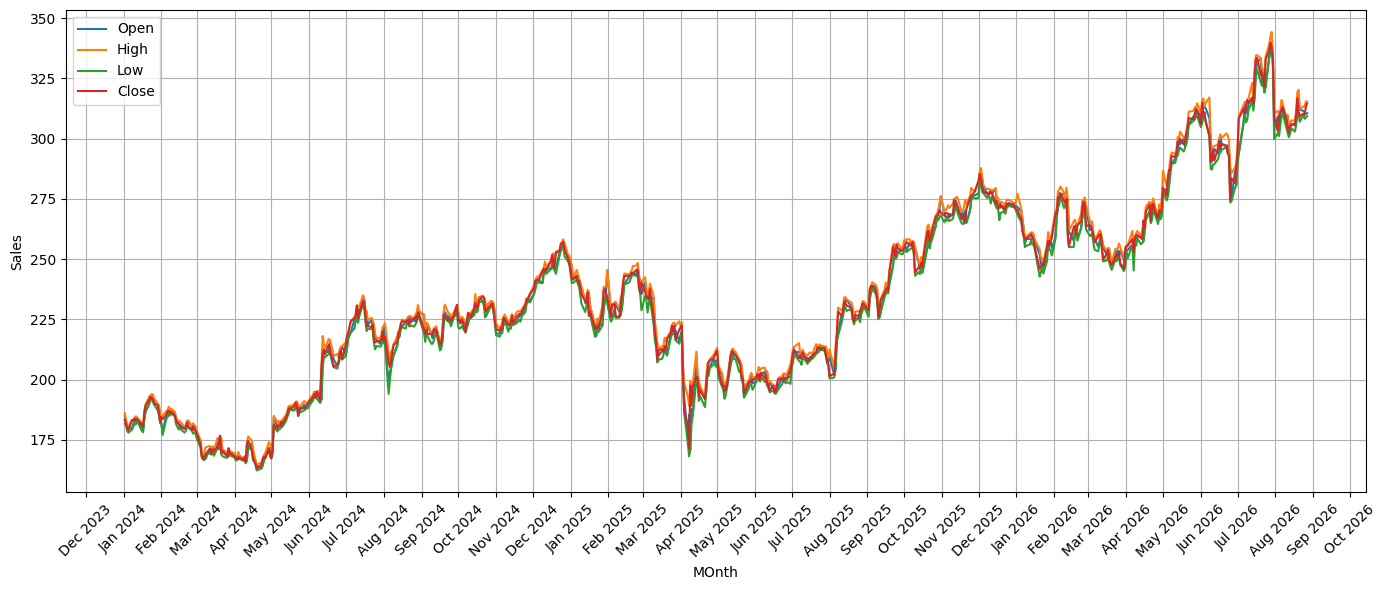

In [10]:
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df.index, df[col], label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1400x500 with 0 Axes>

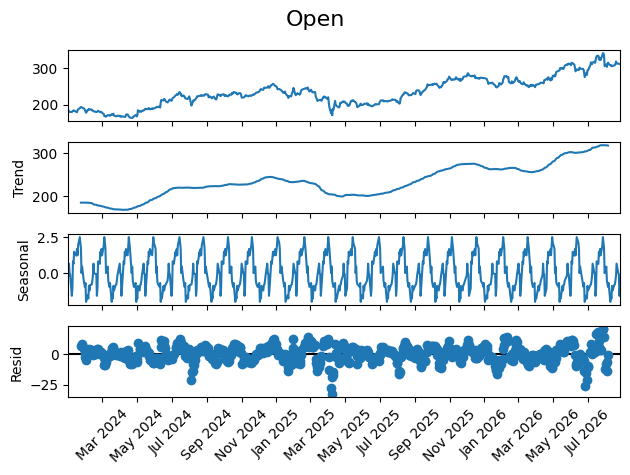

<Figure size 1400x500 with 0 Axes>

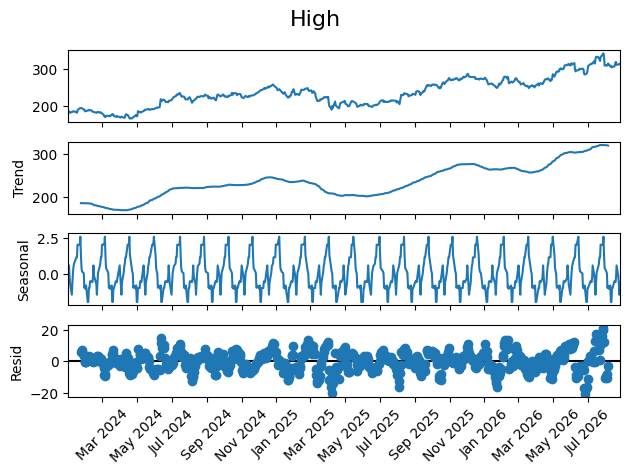

<Figure size 1400x500 with 0 Axes>

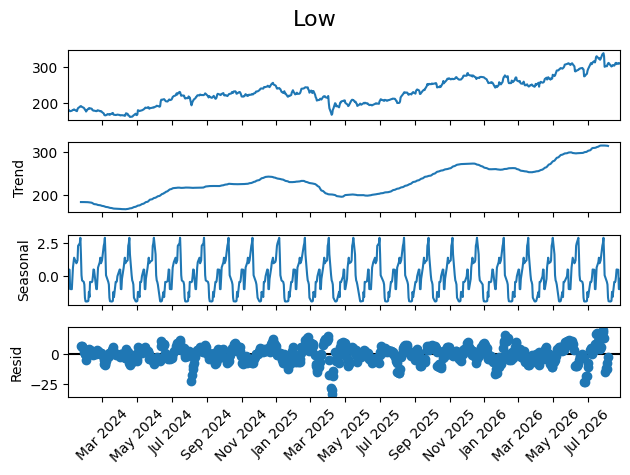

<Figure size 1400x500 with 0 Axes>

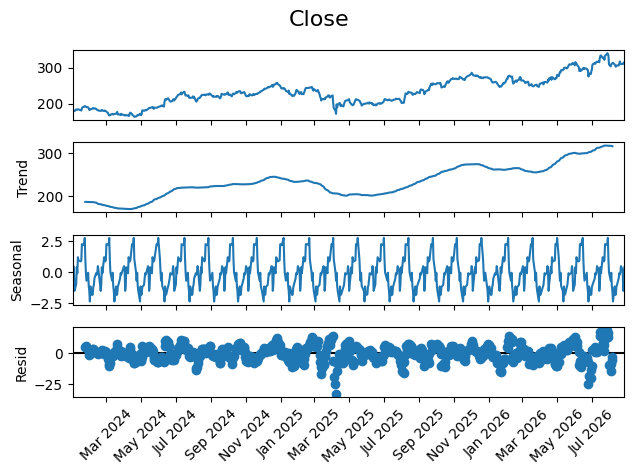

In [12]:
import matplotlib.dates as mdates
for col in ['Open', 'High', 'Low', 'Close']:
    result=seasonal_decompose(
        df[col],model='additive',period=30)
    fig=plt.figure(figsize=(14,5))
    
    result.plot()
    for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.suptitle(col,fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
   
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])

In [14]:
for col in df.columns:
    print(col,adf_test(df[col]))
    print("---")
    print(col,kpss_test(df[col]))

adf stats:-0.699
p-value stats:0.847
('Close', 'AAPL') None
---
KPSS Statistic: 0.32400513470449144
p-value: 0.01
('Close', 'AAPL') None
adf stats:-0.748
p-value stats:0.834
('High', 'AAPL') None
---
KPSS Statistic: 0.324939737921468
p-value: 0.01
('High', 'AAPL') None
adf stats:-0.906
p-value stats:0.786
('Low', 'AAPL') None
---
KPSS Statistic: 0.32316991586091603
p-value: 0.01
('Low', 'AAPL') None
adf stats:-0.987
p-value stats:0.758
('Open', 'AAPL') None
---
KPSS Statistic: 0.32355767585554185
p-value: 0.01
('Open', 'AAPL') None


C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\487204587.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\487204587.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\487204587.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\487204587.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual 

In [15]:
df_diff=df.diff().dropna()

In [16]:
df_diff

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-03,-1.373276,-2.529182,-0.454484,-2.894720
2024-01-04,-2.311798,-2.756390,-2.519260,-2.045061
2024-01-05,-0.721237,-0.326046,-0.701474,-0.158080
2024-01-08,4.327255,2.805811,1.313989,0.098793
2024-01-09,-0.414932,-0.444585,1.215188,1.807967
...,...,...,...,...
2026-08-21,-1.949982,-7.899994,-3.639984,-5.410004
2026-08-24,0.989990,0.979980,2.959991,-0.579987


In [17]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
   
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    

In [18]:
for col in ['Open', 'High', 'Low', 'Close']:
    adf_test(df_diff[col])
    kpss_test(df_diff[col])

adf stats:-15.733
p-value stats:0.0
KPSS Statistic: 0.0371278176744892
p-value: 0.1
adf stats:-14.001
p-value stats:0.0
KPSS Statistic: 0.04038094775444315
p-value: 0.1
adf stats:-13.985
p-value stats:0.0
KPSS Statistic: 0.036125840991394306
p-value: 0.1
adf stats:-13.064
p-value stats:0.0
KPSS Statistic: 0.036646556701156685
p-value: 0.1


C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_16432\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual 

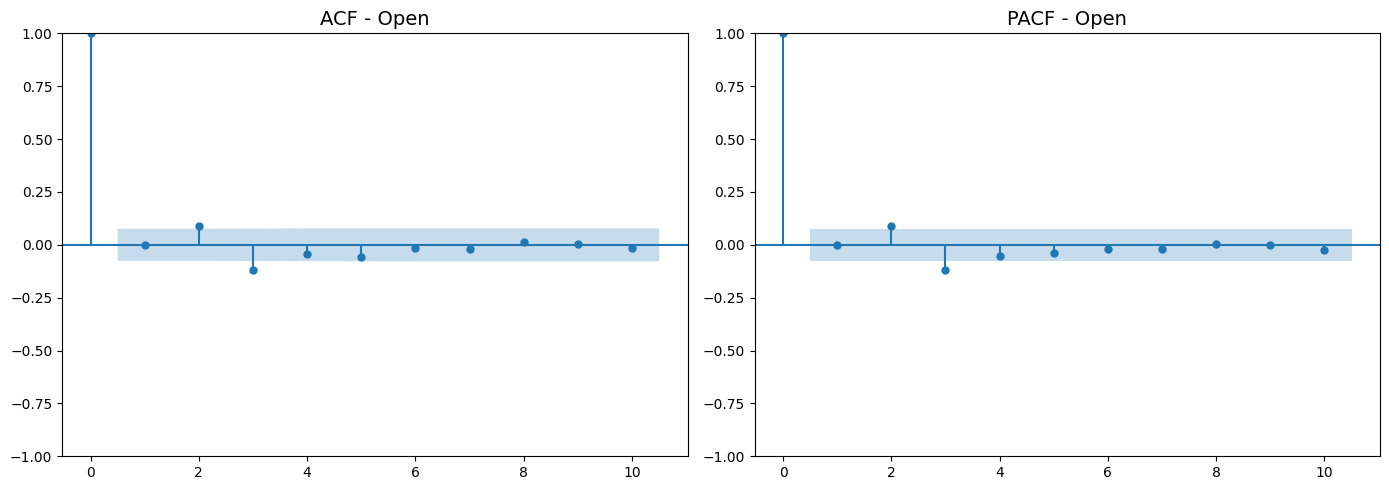

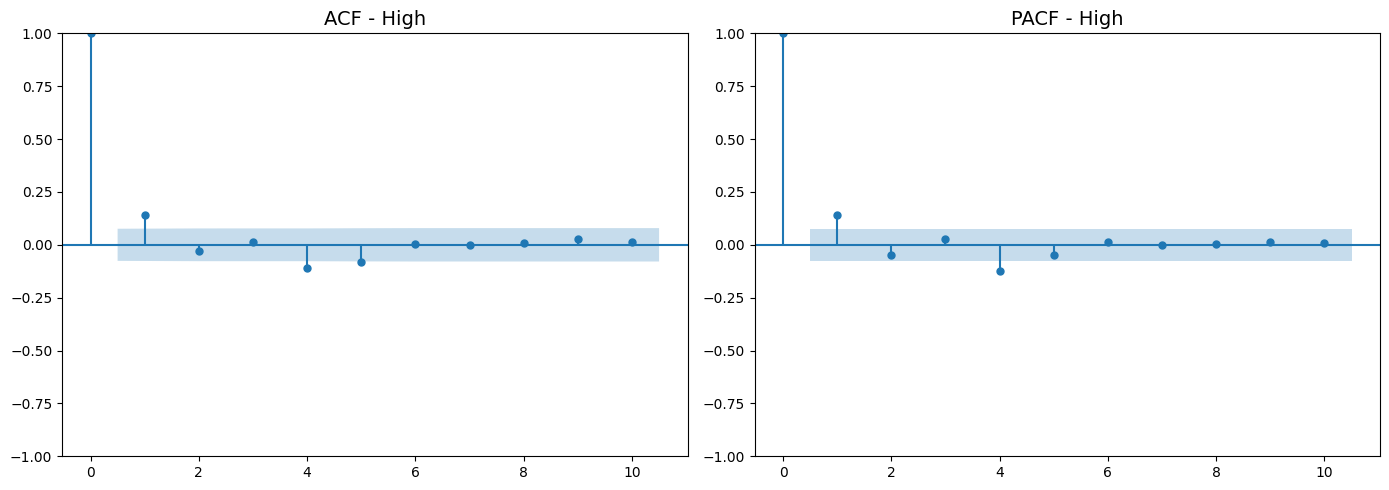

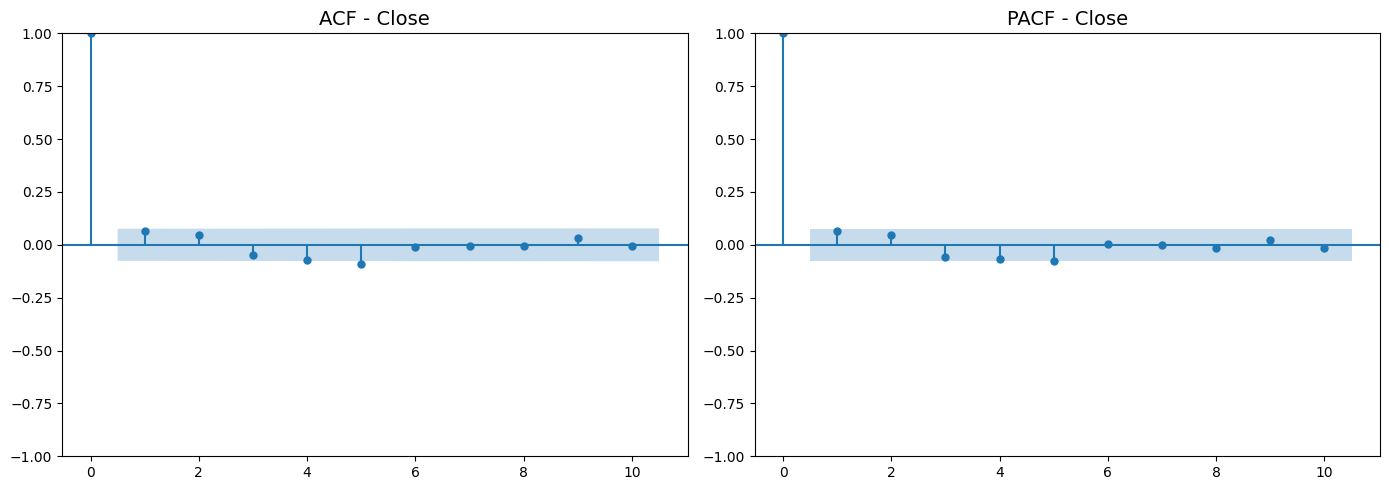

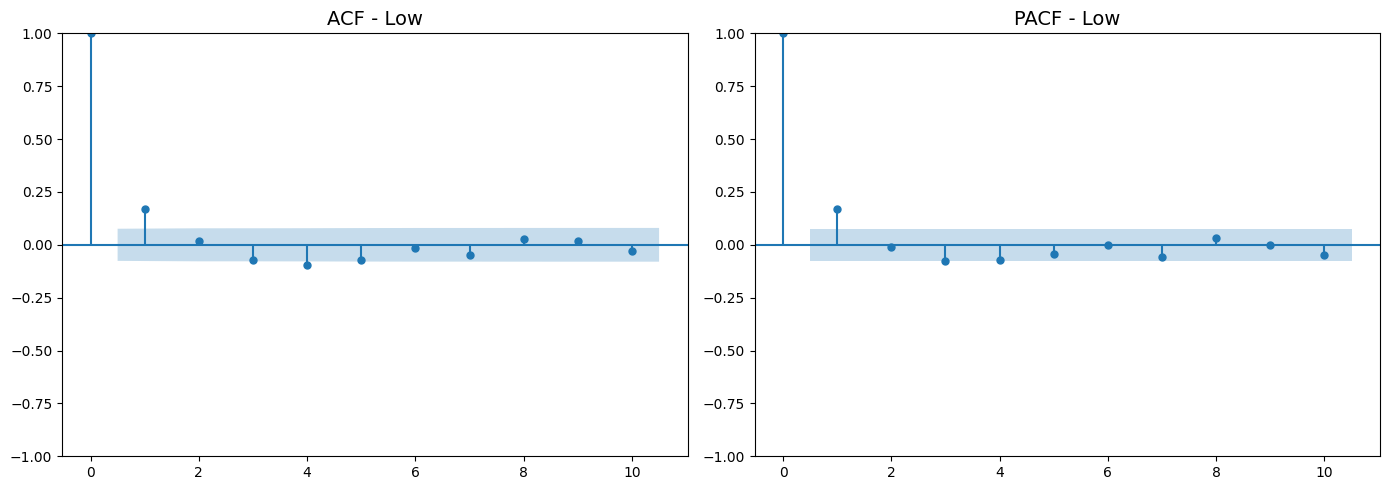

In [19]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
for col in ['Open', 'High', 'Close', 'Low']:
    data = df_diff[col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # ACF
    plot_acf(data, lags=10, ax=axes[0])
    axes[0].set_title(f'ACF - {col}', fontsize=14)
    # PACF
    plot_pacf(data, lags=10, ax=axes[1])
    axes[1].set_title(f'PACF - {col}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [20]:
train=df_diff[:600]
test=df_diff[600:]

In [21]:
from statsmodels.tsa.api import VAR

In [22]:
model = VAR(train)
lag_selection = model.select_order(maxlags=30)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [23]:
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        7.391       7.421       1621.       7.403
1        6.271       6.424       529.1       6.331
2        5.905       6.179       366.7       6.012
3        5.777       6.173       322.7       5.932
4        5.585      6.103*       266.4       5.787
5        5.535       6.175       253.3      5.784*
6       5.521*       6.283      249.9*       5.818
7        5.544       6.429       255.9       5.889
8        5.569       6.575       262.2       5.961
9        5.557       6.685       259.2       5.997
10       5.563       6.813       260.9       6.051
11       5.580       6.953       265.5       6.116
12       5.580       7.074       265.5       6.163
13       5.598       7.214       270.4       6.228
14       5.602       7.340       271.6       6.280
15       5.625       7.486       278.3       6.351
16       5.642       7.625     

In [24]:
lag_selection

In [25]:
lag_order = lag_selection.selected_orders['bic']

print("Selected lag:", lag_order)

Selected lag: 4


In [26]:
results = model.fit(lag_order)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 30, Aug, 2026
Time:                     11:13:20
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    5.96844
Nobs:                     596.000    HQIC:                   5.66259
Log likelihood:          -4944.08    FPE:                    236.892
AIC:                      5.46754    Det(Omega_mle):         211.687
--------------------------------------------------------------------
Results for equation Close_AAPL
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.203322         0.150535            1.351           0.177
L1.Close_AAPL         0.222599         0.105419            2.112           0.035
L1.High_AAPL         -0.213009         0.108956        

In [27]:
forecast = results.forecast(
    train.values[-results.k_ar:],
    steps=len(test)
)

In [28]:
forecast

array([[-0.10806691, -1.29036204, -1.79098998, -1.86190417],
       [-0.11517781, -0.11313666, -0.32760054, -0.65302855],
       [-0.06598421,  0.14430797,  0.20398182,  0.22516926],
       [ 0.11968006,  0.26103698,  0.44069394,  0.24766233],
       [ 0.18166197,  0.14501511,  0.08356905,  0.27361755],
       [ 0.24467129,  0.09584187, -0.08115841, -0.04313789],
       [ 0.24506064,  0.25795622,  0.30733481,  0.18092912],
       [ 0.25830351,  0.30732143,  0.33862228,  0.35410064],
       [ 0.20043227,  0.22126229,  0.28509293,  0.29838365],
       [ 0.19318031,  0.18065682,  0.13540277,  0.16022329],
       [ 0.20117617,  0.19616817,  0.15180663,  0.1635697 ],
       [ 0.20379514,  0.20842295,  0.22940518,  0.19509541],
       [ 0.20930725,  0.21980105,  0.22072622,  0.23016898],
       [ 0.20745055,  0.20612249,  0.21055403,  0.21554898],
       [ 0.20522971,  0.20495461,  0.19406716,  0.19456785],
       [ 0.2084391 ,  0.21193253,  0.20222932,  0.20347868],
       [ 0.20616882,  0.

In [31]:
forecast_diff = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)

In [35]:
last_train_value = data.loc[train.index[-1]]
last_train_value

Ticker
AAPL    1.828445
Name: 2026-05-26 00:00:00, dtype: float64

In [33]:
forecast_level = (
    last_train_value + forecast_diff.cumsum()
)

In [34]:
forecast_level

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2026-05-27,NaN,NaN,NaN,NaN
2026-05-28,NaN,NaN,NaN,NaN
2026-05-29,NaN,NaN,NaN,NaN
2026-06-01,NaN,NaN,NaN,NaN
2026-06-02,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-08-21,NaN,NaN,NaN,NaN
2026-08-24,NaN,NaN,NaN,NaN
